# 02 — CoT step entropy

For chain-of-thought answers, the interesting unit is not the token but the
**reasoning step**. `split_steps` segments the generated tokens into
sentence (or custom) steps, and `EntropyTrajectory` aggregates entropy per
step: where does the model's uncertainty collapse — and where does it spike?

This notebook uses structured synthetic entropies so it runs offline; the
last section shows the live-server version.

In [1]:
import numpy as np

from entropy_lens.trajectory import EntropyTrajectory, split_steps

answer = (
    "First, multiply 3 boxes by 12 pencils to get 36 pencils. "
    "Then, subtract the 7 pencils Maria gave away. "
    "That leaves 36 minus 7, which is 29. "
    "The answer is 29."
)

words = answer.split(" ")
tokens = [words[0]] + [" " + w for w in words[1:]]  # crude BPE-style tokens
boundaries = split_steps(tokens, "sentence")
boundaries

[0, 11, 19, 27]

In [2]:
# Synthetic per-token entropies: each step opens uncertain and settles,
# later steps are overall more confident (a typical CoT pattern).
rng = np.random.default_rng(7)
h = np.empty(len(tokens))
bounds = [*boundaries, len(tokens)]
for step, (a, b) in enumerate(zip(bounds[:-1], bounds[1:], strict=False)):
    within = np.linspace(1.6, 0.6, b - a)
    h[a:b] = (1.8 * 0.65**step + 0.15) * within + rng.gamma(2.0, 0.18, b - a)

traj = EntropyTrajectory(h, tokens, boundaries)
traj.summary()

{'n_tokens': 31,
 'n_steps': 4,
 'base': 'bits',
 'mean_entropy': 1.7681714734686522,
 'max_entropy': 3.420285952614259,
 'min_entropy': 0.48664105087510023,
 'first_step_mean': 2.3746695367783577,
 'last_step_mean': 0.947967232066599,
 'total_decrease': 1.4267023047117586,
 'monotonic_fraction': 1.0}

`step_means()` gives the step-level trajectory and `delta_h()` the change
between consecutive steps — negative ΔH means the model got more confident.

In [3]:
for i, (text, mean) in enumerate(zip(traj.step_texts(), traj.step_means(), strict=True), 1):
    print(f"step {i}: mean H = {mean:.3f} bits | {text.strip()}")
print("\nΔH between steps:", np.round(traj.delta_h(), 3))

step 1: mean H = 2.375 bits | First, multiply 3 boxes by 12 pencils to get 36 pencils.
step 2: mean H = 1.722 bits | Then, subtract the 7 pencils Maria gave away.
step 3: mean H = 1.391 bits | That leaves 36 minus 7, which is 29.
step 4: mean H = 0.948 bits | The answer is 29.

ΔH between steps: [-0.653 -0.331 -0.443]


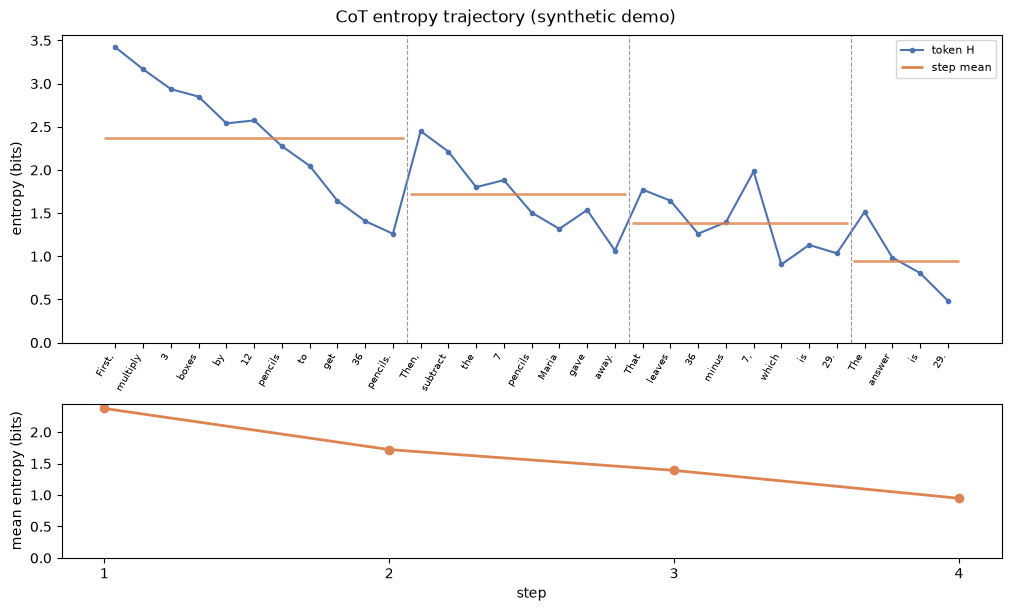

In [4]:
from entropy_lens.viz import plot_trajectory

plot_trajectory(traj, title="CoT entropy trajectory (synthetic demo)", show_tokens=True);

## Live version

With a vLLM server running (`vllm serve Qwen/Qwen2.5-0.5B-Instruct
--max-logprobs 20`), the same analysis on real logprobs is:

```python
from openai import OpenAI
from entropy_lens.adapters import from_openai_response

client = OpenAI(base_url="http://localhost:8000/v1", api_key="EMPTY")
response = client.chat.completions.create(
    model="Qwen/Qwen2.5-0.5B-Instruct",
    messages=[{"role": "user", "content": (
        "A shop sells pencils in boxes of 12. Maria buys 3 boxes and gives "
        "away 7 pencils. How many pencils does she have left? "
        "Think step by step in short sentences."
    )}],
    max_tokens=256,
    logprobs=True,
    top_logprobs=20,
)
traj = from_openai_response(response, split="sentence")
```

or simply `python scripts/verify_trajectory.py --base-url http://localhost:8000/v1`.

Interpretation notes:
- a *decreasing* step trajectory shows the model converging — but converging
  confidently is **not** the same as converging to the right answer;
- an entropy *spike* mid-reasoning marks a genuine branch point, often a good
  place to look when a CoT goes wrong.